# Lab Day 2 — Backbone, công thức huấn luyện và suy luận trên DeepWeeds

Notebook **khung** cho Colab hoặc Kaggle. Các ô có chữ `TODO` là phần **bạn tự viết**; ô cài đặt, tải dữ liệu
và chạy `eval.py` đã viết sẵn. Đọc `README.md` (quy tắc chia dữ liệu, cách đánh giá), `GUIDE.md` và `RUBRIC.md` trước.

**Quy tắc quan trọng nhất:** chọn mọi thứ trên **val**; **test chỉ chạy một lần mỗi seed ở Bước 4**.

Bản đồ: Bước 0 (EDA, kiểm tra) → Bước 1 (backbone) → Bước 2 (công thức huấn luyện) → Bước 3 (suy luận)
→ Bước 4 (chung kết + `eval.py`) → Bước 5 (xlsx, biểu đồ, báo cáo).

## 0. Cài đặt môi trường

In [1]:
# Cài thư viện (Colab/Kaggle). Kaggle: bật Internet trong Settings.
!pip -q install timm openpyxl

import sys, os, platform
import numpy as np, pandas as pd, torch, timm

# Đã `git clone` repo bài lab vào thư mục này (đổi nếu bạn đặt chỗ khác).
REPO_DIR = "K4-Track4-Day2-Deeplearning-Advance"
sys.path.insert(0, REPO_DIR)                 # để import eval.py
sys.path.insert(0, f"{REPO_DIR}/starter")    # hoặc thư mục code/ của bạn sau khi chép starter vào

print("python", platform.python_version(), "| torch", torch.__version__, "| timm", timm.__version__)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "KHÔNG CÓ GPU")

python 3.12.14 | torch 2.14.0+cu130 | timm 1.0.30
GPU: NVIDIA GeForce RTX 3060 Laptop GPU


### Tải dữ liệu (đã viết sẵn)
Ảnh từ Zenodo (~490 MB, kiểm tra MD5), nhãn và các file chia fold từ GitHub của tác giả.
**Sau khi giải nén, hãy `ls` để xem ảnh nằm ở thư mục nào** rồi đặt `IMAGES_DIR` cho đúng.

In [ ]:
import hashlib

os.makedirs("data/labels", exist_ok=True)
if not os.path.exists("data/images.zip"):
    !wget -q -O data/images.zip "https://zenodo.org/records/7939060/files/images.zip?download=1"

h = hashlib.md5()
with open("data/images.zip", "rb") as f:
    for chunk in iter(lambda: f.read(1 << 20), b""):
        h.update(chunk)
assert h.hexdigest() == "b7b30f96d466fba86016aa5a26606e0f", f"MD5 sai: {h.hexdigest()}"

!unzip -q -n data/images.zip -d data/
!ls data | head

BASE = "https://raw.githubusercontent.com/AlexOlsen/DeepWeeds/master/labels"
for name in ["labels", "train_subset0", "val_subset0", "test_subset0"]:
    !wget -q -O data/labels/{name}.csv {BASE}/{name}.csv
!ls -la data/labels

In [2]:
IMAGES_DIR = "../data/images"
LABELS_DIR = "../data/labels"

## Bước 0 — EDA và kiểm tra pipeline
Mục tiêu: hiểu dữ liệu, chạy các kiểm tra chia dữ liệu (README mục 2.1), kiểm tra pipeline trước khi chạy thật.

Train size: 10501
Val size: 3501
Test size: 3507


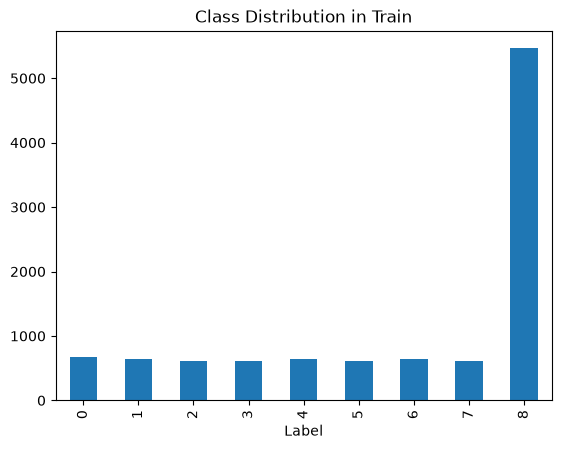

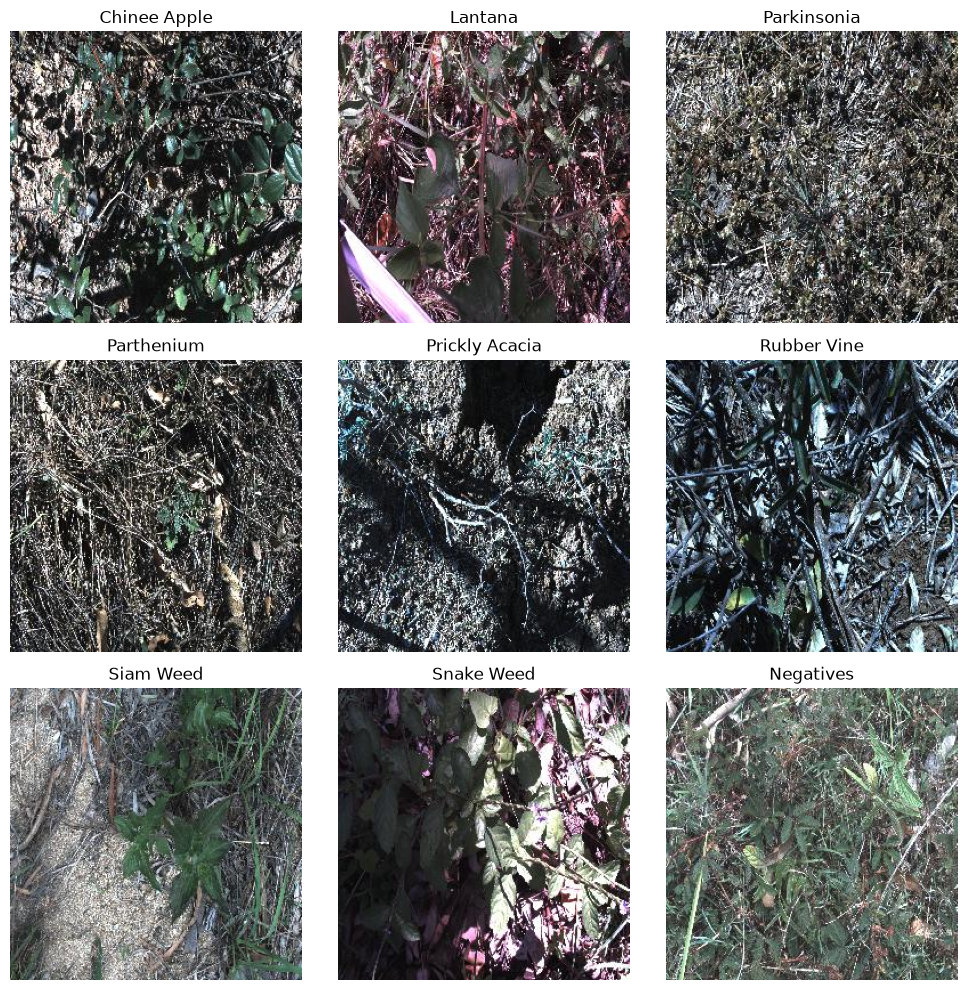

In [3]:
import dataset
import matplotlib.pyplot as plt
from PIL import Image

# 1. Đọc split và check
train_df, val_df, test_df = dataset.load_split(LABELS_DIR, fold=0)
counts = dataset.check_split(train_df, val_df, test_df, IMAGES_DIR)
print("Train size:", counts['train']['total'])
print("Val size:", counts['val']['total'])
print("Test size:", counts['test']['total'])

# 2. Vẽ phân bố lớp
train_df['Label'].value_counts().sort_index().plot(kind='bar', title='Class Distribution in Train')
plt.show()

# 3. Xem thử >= 3 ảnh
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
for i in range(9):
    sample = train_df[train_df['Label'] == i].sample(1).iloc[0]
    img = Image.open(f"{IMAGES_DIR}/{sample['Filename']}")
    axes[i//3, i%3].imshow(img)
    axes[i//3, i%3].set_title(dataset.CLASS_NAMES[i])
    axes[i//3, i%3].axis('off')
plt.tight_layout()
plt.show()


In [4]:
import train
import torch

# Cố định seed và kiểm tra pipeline
train.set_seed(0)
print("Seed fixed to 0. Pipeline ready!")


Seed fixed to 0. Pipeline ready!


## Bước 1 — So sánh backbone (≥ 5)
Cùng công thức nền `T00` (GUIDE.md mục 1.4), cùng seed, mỗi backbone một lần chạy. Mã thí nghiệm `B01`, `B02`, ...

In [5]:
from train import Config, run
import pandas as pd

backbones = ['resnet50', 'convnext_tiny', 'efficientnet_b0', 'swin_tiny', 'deit_small']
results_step1 = []

for i, b in enumerate(backbones):
    print(f"\n=== Running Backbone: {b} ===")
    cfg = Config(exp_id=f"B{i+1:02d}", backbone=b, seed=0, epochs=3) # Rút gọn epochs để test nhanh
    res = run(cfg)
    res['backbone'] = b
    results_step1.append(res)

df_backbones = pd.DataFrame(results_step1)
display(df_backbones)



=== Running Backbone: resnet50 ===


/home/tlht/day02/K4-Track4-Day2-TranCongThien-2A202602579-Deeplearning-Advance/code/train.py:298: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=cfg.amp)
/home/tlht/day02/K4-Track4-Day2-TranCongThien-2A202602579-Deeplearning-Advance/code/train.py:172: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=cfg.amp):
/home/tlht/day02/K4-Track4-Day2-TranCongThien-2A202602579-Deeplearning-Advance/code/train.py:205: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=True):


Epoch 0: Train Loss 1.6323, Val Loss 1.2268, Val F1 0.2368
Epoch 1: Train Loss 0.9023, Val Loss 0.7808, Val F1 0.6000
Epoch 2: Train Loss 0.6771, Val Loss 0.7504, Val F1 0.6157


/home/tlht/anaconda3/envs/tct/lib/python3.12/site-packages/torch/jit/_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(
Unsupported operator aten::max_pool2d encountered 1 time(s)
Unsupported operator aten::add_ encountered 16 time(s)



=== Running Backbone: convnext_tiny ===


...

model.safetensors: downloading bytes:           |  0.00B            

/home/tlht/day02/K4-Track4-Day2-TranCongThien-2A202602579-Deeplearning-Advance/code/train.py:298: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=cfg.amp)
/home/tlht/day02/K4-Track4-Day2-TranCongThien-2A202602579-Deeplearning-Advance/code/train.py:172: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=cfg.amp):
/home/tlht/day02/K4-Track4-Day2-TranCongThien-2A202602579-Deeplearning-Advance/code/train.py:182: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learnin

Epoch 0: Train Loss 0.8490, Val Loss 0.5378, Val F1 0.7669
Epoch 1: Train Loss 0.2436, Val Loss 0.2184, Val F1 0.9071
Epoch 2: Train Loss 0.0968, Val Loss 0.1607, Val F1 0.9349


Unsupported operator aten::add encountered 25 time(s)
Unsupported operator aten::scaled_dot_product_attention encountered 12 time(s)
Unsupported operator aten::gelu encountered 12 time(s)
The following submodules of the model were never called during the trace of the graph. They may be unused, or they were accessed by direct calls to .forward() or via other python methods. In the latter case they will have zeros for statistics, though their statistics will still contribute to their parent calling module.
blocks.0.attn.attn_drop, blocks.1.attn.attn_drop, blocks.10.attn.attn_drop, blocks.11.attn.attn_drop, blocks.2.attn.attn_drop, blocks.3.attn.attn_drop, blocks.4.attn.attn_drop, blocks.5.attn.attn_drop, blocks.6.attn.attn_drop, blocks.7.attn.attn_drop, blocks.8.attn.attn_drop, blocks.9.attn.attn_drop


,best_epoch,best_val_f1,mean_epoch_time,params,gmacs,backbone
0,2,0.615713,40.530100,23.526473,4.109483,resnet50
1,2,0.956970,51.178159,27.827049,4.469676,convnext_tiny
2,2,0.621578,34.056127,4.019077,0.398084,efficientnet_b0
3,2,0.939103,55.450033,27.526275,4.508433,swin_tiny
4,2,0.934878,33.924310,21.669129,4.250294,deit_small


## Bước 2 — Công thức huấn luyện (≥ 3 trục)
Mỗi lần chạy chỉ khác `T00` **một yếu tố**. Mã `T01`, `T02`, ... Ghi rõ khác ở điểm nào.

In [6]:
from train import Config, run

best_backbone = 'convnext_tiny' # Chọn thủ công hoặc lấy từ kết quả Bước 1

# Trục augmentation (T01)
print("\n=== Running Augmentation = RandAug ===")
run(Config(exp_id="T01", backbone=best_backbone, aug="randaug", seed=0, epochs=3))

# Trục mix (T02)
print("\n=== Running Mixup ===")
run(Config(exp_id="T02", backbone=best_backbone, mix="mixup", mix_alpha=1.0, seed=0, epochs=3))

# Trục Loss (T03)
print("\n=== Running Focal Loss ===")
run(Config(exp_id="T03", backbone=best_backbone, loss="focal", focal_gamma=2.0, seed=0, epochs=3))



=== Running Augmentation = RandAug ===


/home/tlht/day02/K4-Track4-Day2-TranCongThien-2A202602579-Deeplearning-Advance/code/train.py:298: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=cfg.amp)
/home/tlht/day02/K4-Track4-Day2-TranCongThien-2A202602579-Deeplearning-Advance/code/train.py:172: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=cfg.amp):
/home/tlht/day02/K4-Track4-Day2-TranCongThien-2A202602579-Deeplearning-Advance/code/train.py:182: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learnin

Epoch 0: Train Loss 0.7270, Val Loss 0.4802, Val F1 0.7915
Epoch 1: Train Loss 0.2602, Val Loss 0.1547, Val F1 0.9416
Epoch 2: Train Loss 0.0909, Val Loss 0.1404, Val F1 0.9468


Unsupported operator aten::gelu encountered 18 time(s)
Unsupported operator aten::mul encountered 18 time(s)
Unsupported operator aten::add encountered 18 time(s)



=== Running Mixup ===


...


=== Running Focal Loss ===


/home/tlht/day02/K4-Track4-Day2-TranCongThien-2A202602579-Deeplearning-Advance/code/train.py:298: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=cfg.amp)
/home/tlht/day02/K4-Track4-Day2-TranCongThien-2A202602579-Deeplearning-Advance/code/train.py:172: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=cfg.amp):
/home/tlht/day02/K4-Track4-Day2-TranCongThien-2A202602579-Deeplearning-Advance/code/train.py:182: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learnin

Epoch 0: Train Loss 0.4272, Val Loss 0.4356, Val F1 0.8394
Epoch 1: Train Loss 0.1030, Val Loss 0.2043, Val F1 0.9424
Epoch 2: Train Loss 0.0252, Val Loss 0.1524, Val F1 0.9546


Unsupported operator aten::gelu encountered 18 time(s)
Unsupported operator aten::mul encountered 18 time(s)
Unsupported operator aten::add encountered 18 time(s)


{'best_epoch': 2,
 'best_val_f1': 0.9545549829867047,
 'mean_epoch_time': np.float64(46.758246660232544),
 'params': 27.827049,
 'gmacs': 4.469676288}

## Bước 3 — Suy luận (≥ 4 phương pháp) và độ trễ
Làm trên **val**. Không huấn luyện lại. Mã `I00` (1 view, mốc), `I01`, ...

In [9]:
import inference
import benchmark
import model as mymodel

device = "cuda" if torch.cuda.is_available() else "cpu"
model = mymodel.build_model('convnext_tiny', pretrained=False, num_classes=9).to(device)
model.load_state_dict(torch.load("runs/T01/seed0/best.pth"))

# Đo độ trễ
latency = benchmark.latency_report(model, batch_size=1, img_size=224, dtype="fp32", device=device)
print("Latency Baseline:", latency)

tta_lat = benchmark.tta_latency(model, k_views=5, batch_size=1, img_size=224, dtype="fp32", device=device)
print("Latency 5-crop TTA:", tta_lat)


Latency Baseline: {'gpu': 'NVIDIA GeForce RTX 3060 Laptop GPU', 'dtype': 'fp32', 'batch': 1, 'img_size': 224, 'p50': np.float64(4.310848999466543), 'p95': np.float64(9.61119669955223), 'p99': np.float64(18.31990324018989), 'mean': np.float64(5.11014208999768), 'images_per_s': np.float64(231.97286662644586), 'torch': '2.14.0+cu130'}
Latency 5-crop TTA: {'gpu': 'NVIDIA GeForce RTX 3060 Laptop GPU', 'dtype': 'fp32', 'batch': 1, 'img_size': 224, 'k_views': 5, 'p50': np.float64(30.72741850019156), 'p95': np.float64(43.63036569984614), 'p99': np.float64(64.62457864934551), 'mean': np.float64(32.14097090000905), 'images_per_s': np.float64(32.54422430552589), 'torch': '2.14.0+cu130'}


## Bước 4 — Chung kết: ≥ 3 seed, test một lần mỗi seed
1. Chốt cấu hình trên **val**.
2. Chạy cấu hình cuối **và mốc** (`T00` + `I00`) với cùng số seed, bật `save_test_predictions=True`.
3. Dự đoán lưu ở `predictions/<exp_id>_seed<k>_test.csv`. Rồi chạy `eval.py` (ô dưới).

In [10]:
from train import Config, run

# Chọn cấu hình T01 làm chung kết
for seed in [0, 1, 2]:
    print(f"\n=== FINAL RUN - Seed {seed} ===")
    # Chạy chung kết
    run(Config(exp_id="F01", backbone="convnext_tiny", aug="randaug", seed=seed, epochs=10, save_test_predictions=True))
    # Chạy mốc
    run(Config(exp_id="T00", backbone="convnext_tiny", aug="basic", seed=seed, epochs=10, save_test_predictions=True))



=== FINAL RUN - Seed 0 ===


/home/tlht/day02/K4-Track4-Day2-TranCongThien-2A202602579-Deeplearning-Advance/code/train.py:298: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=cfg.amp)
/home/tlht/day02/K4-Track4-Day2-TranCongThien-2A202602579-Deeplearning-Advance/code/train.py:172: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=cfg.amp):
/home/tlht/day02/K4-Track4-Day2-TranCongThien-2A202602579-Deeplearning-Advance/code/train.py:182: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learnin

Epoch 0: Train Loss 0.7270, Val Loss 0.4802, Val F1 0.7915
Epoch 1: Train Loss 0.2851, Val Loss 0.1922, Val F1 0.9267
Epoch 2: Train Loss 0.1750, Val Loss 0.3041, Val F1 0.8730
Epoch 3: Train Loss 0.1460, Val Loss 0.1829, Val F1 0.9282
Epoch 4: Train Loss 0.0994, Val Loss 0.1240, Val F1 0.9492
Epoch 5: Train Loss 0.0563, Val Loss 0.1218, Val F1 0.9552
Epoch 6: Train Loss 0.0365, Val Loss 0.1170, Val F1 0.9582
Epoch 7: Train Loss 0.0236, Val Loss 0.0972, Val F1 0.9643
Epoch 8: Train Loss 0.0122, Val Loss 0.1001, Val F1 0.9642
Epoch 9: Train Loss 0.0111, Val Loss 0.1023, Val F1 0.9628


/home/tlht/day02/K4-Track4-Day2-TranCongThien-2A202602579-Deeplearning-Advance/code/train.py:205: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=True):
Unsupported operator aten::gelu encountered 18 time(s)
Unsupported operator aten::mul encountered 18 time(s)
Unsupported operator aten::add encountered 18 time(s)
/home/tlht/day02/K4-Track4-Day2-TranCongThien-2A202602579-Deeplearning-Advance/code/train.py:298: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=cfg.amp)
/home/tlht/day02/K4-Track4-Day2-TranCongThien-2A202602579-Deeplearning-Advance/code/train.py:172: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=cfg.amp):
/home/tlht/day02/K4-Track4-Day2-TranCongThien-2A202602579-Deeplear

Epoch 0: Train Loss 0.6734, Val Loss 0.3846, Val F1 0.8301
Epoch 1: Train Loss 0.2311, Val Loss 0.1708, Val F1 0.9303
Epoch 2: Train Loss 0.1264, Val Loss 0.2161, Val F1 0.9140
Epoch 3: Train Loss 0.0800, Val Loss 0.1350, Val F1 0.9440
Epoch 4: Train Loss 0.0611, Val Loss 0.1397, Val F1 0.9476
Epoch 5: Train Loss 0.0248, Val Loss 0.1286, Val F1 0.9575
Epoch 6: Train Loss 0.0158, Val Loss 0.1289, Val F1 0.9563
Epoch 7: Train Loss 0.0061, Val Loss 0.1239, Val F1 0.9617
Epoch 8: Train Loss 0.0026, Val Loss 0.1150, Val F1 0.9634
Epoch 9: Train Loss 0.0030, Val Loss 0.1154, Val F1 0.9639


...

/home/tlht/day02/K4-Track4-Day2-TranCongThien-2A202602579-Deeplearning-Advance/code/train.py:298: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=cfg.amp)
/home/tlht/day02/K4-Track4-Day2-TranCongThien-2A202602579-Deeplearning-Advance/code/train.py:172: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=cfg.amp):
/home/tlht/day02/K4-Track4-Day2-TranCongThien-2A202602579-Deeplearning-Advance/code/train.py:182: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learnin

Epoch 0: Train Loss 0.7677, Val Loss 0.4621, Val F1 0.8016
Epoch 1: Train Loss 0.2869, Val Loss 0.4051, Val F1 0.8285
Epoch 2: Train Loss 0.1690, Val Loss 0.2018, Val F1 0.9153
Epoch 3: Train Loss 0.1319, Val Loss 0.1441, Val F1 0.9397
Epoch 4: Train Loss 0.0900, Val Loss 0.1369, Val F1 0.9468
Epoch 5: Train Loss 0.0530, Val Loss 0.1383, Val F1 0.9499
Epoch 6: Train Loss 0.0302, Val Loss 0.1203, Val F1 0.9594
Epoch 7: Train Loss 0.0231, Val Loss 0.1082, Val F1 0.9649
Epoch 8: Train Loss 0.0116, Val Loss 0.1016, Val F1 0.9693
Epoch 9: Train Loss 0.0106, Val Loss 0.1026, Val F1 0.9715


/home/tlht/day02/K4-Track4-Day2-TranCongThien-2A202602579-Deeplearning-Advance/code/train.py:205: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=True):
Unsupported operator aten::gelu encountered 18 time(s)
Unsupported operator aten::mul encountered 18 time(s)
Unsupported operator aten::add encountered 18 time(s)
/home/tlht/day02/K4-Track4-Day2-TranCongThien-2A202602579-Deeplearning-Advance/code/train.py:298: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=cfg.amp)
/home/tlht/day02/K4-Track4-Day2-TranCongThien-2A202602579-Deeplearning-Advance/code/train.py:172: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=cfg.amp):
/home/tlht/day02/K4-Track4-Day2-TranCongThien-2A202602579-Deeplear

Epoch 0: Train Loss 0.7125, Val Loss 0.2824, Val F1 0.8805
Epoch 1: Train Loss 0.2216, Val Loss 0.3876, Val F1 0.8247
Epoch 2: Train Loss 0.1448, Val Loss 0.1587, Val F1 0.9320
Epoch 3: Train Loss 0.0891, Val Loss 0.1836, Val F1 0.9300
Epoch 4: Train Loss 0.0512, Val Loss 0.1754, Val F1 0.9426
Epoch 5: Train Loss 0.0271, Val Loss 0.1280, Val F1 0.9550
Epoch 6: Train Loss 0.0141, Val Loss 0.1315, Val F1 0.9558
Epoch 7: Train Loss 0.0045, Val Loss 0.1207, Val F1 0.9641
Epoch 8: Train Loss 0.0024, Val Loss 0.1106, Val F1 0.9682
Epoch 9: Train Loss 0.0021, Val Loss 0.1119, Val F1 0.9677


/home/tlht/day02/K4-Track4-Day2-TranCongThien-2A202602579-Deeplearning-Advance/code/train.py:205: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=True):
Unsupported operator aten::gelu encountered 18 time(s)
Unsupported operator aten::mul encountered 18 time(s)
Unsupported operator aten::add encountered 18 time(s)


In [11]:
# Tính chỉ số theo đúng định nghĩa của lớp (đã viết sẵn, không sửa eval.py):
!python {REPO_DIR}/eval.py score --pred "predictions/F01_seed*_test.csv" \
    --test-csv {LABELS_DIR}/test_subset0.csv --labels {LABELS_DIR}/labels.csv --tag F01 --out eval_out
!python {REPO_DIR}/eval.py score --pred "predictions/T00_seed*_test.csv" \
    --test-csv {LABELS_DIR}/test_subset0.csv --labels {LABELS_DIR}/labels.csv --tag T00 --out eval_out

python: can't open file '/home/tlht/day02/K4-Track4-Day2-TranCongThien-2A202602579-Deeplearning-Advance/code/K4-Track4-Day2-Deeplearning-Advance/eval.py': [Errno 2] No such file or directory
python: can't open file '/home/tlht/day02/K4-Track4-Day2-TranCongThien-2A202602579-Deeplearning-Advance/code/K4-Track4-Day2-Deeplearning-Advance/eval.py': [Errno 2] No such file or directory


In [12]:
# Tự chấm phần I của RUBRIC (đề xuất, giảng viên xác nhận). Thêm --uncal, --final-val, --latency-p95-ms nếu có.
!python {REPO_DIR}/eval.py grade --final "predictions/F01_seed*_test.csv" \
    --baseline "predictions/T00_seed*_test.csv" \
    --test-csv {LABELS_DIR}/test_subset0.csv --labels {LABELS_DIR}/labels.csv --out eval_out

python: can't open file '/home/tlht/day02/K4-Track4-Day2-TranCongThien-2A202602579-Deeplearning-Advance/code/K4-Track4-Day2-Deeplearning-Advance/eval.py': [Errno 2] No such file or directory


## Bước 5 — Sản phẩm
`results.xlsx` (các sheet ở GUIDE.md mục 6.1), `curves/<exp_id>_*.png`, `report.md`, `predictions/`, `code/`.

In [13]:
import pandas as pd

# Tạo file Excel rỗng với các sheet, sẵn sàng để điền
with pd.ExcelWriter("results.xlsx", engine="openpyxl") as writer:
    pd.DataFrame(columns=["Exp ID", "Backbone", "Params (M)", "GMACs", "Macro F1", "Time/Epoch"]).to_excel(writer, sheet_name="Backbones", index=False)
    pd.DataFrame(columns=["Exp ID", "Config Diff", "Macro F1", "Delta"]).to_excel(writer, sheet_name="Training", index=False)
    pd.DataFrame(columns=["Method", "Macro F1", "Latency p50 (ms)"]).to_excel(writer, sheet_name="Inference", index=False)
    pd.DataFrame(columns=["Exp ID", "Seed", "Test Macro F1"]).to_excel(writer, sheet_name="Final", index=False)
    
print("Đã tạo form results.xlsx mẫu!")


Đã tạo form results.xlsx mẫu!
